# Reconocimiento de patentes con OCR

Este notebook arma el pipeline completo de lectura de patentes:

1. Parte del *ground truth* de patentes y corre el detector Luvizon-like para obtener cajas detectadas.
2. Construye un dataset de recortes de patente usando esas detecciones.
3. Aplica distintos preprocesamientos de imagen.
4. Corre varios OCRs (Tesseract, EasyOCR, fast-plate-ocr).
5. Calcula métricas agregadas y las muestra como **figuras** (barras y tabla como imagen).
6. Muestra ejemplos visuales de lecturas de FastPlate (grilla 2×2, 2×1 y un ejemplo único).

In [13]:
from pathlib import Path
import sys

BASE_DIR = Path.cwd()
SRC_CANDIDATES = [
    BASE_DIR / "src",
    BASE_DIR.parent / "src",
]

for d in SRC_CANDIDATES:
    if d.is_dir() and str(d) not in sys.path:
        sys.path.append(str(d))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

from paths import VIDEO01_MP4, XML_VEHICLES_PATH
from groundtruth import build_gt_plates_df
from metrics import run_luvizon_detection_on_gt, compute_ocr_metrics, best_ocr_configs
from ocr_data import build_ocr_dataset_from_detection
from ocr_engines import run_ocr_on_dataset
from visualization import (
    plot_gt_examples_grid,
    plot_plate_preprocessing_grid,
    plot_table_as_image,
    plot_fastplate_best_2x1,
    plot_fastplate_best_2x2,
    plot_fastplate_best_single,
    plot_ocr_summary_bars,
)


In [14]:
import shutil
import pytesseract

# Config explícita para Tesseract en tu Windows
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

print("tesseract_cmd:", pytesseract.pytesseract.tesseract_cmd)
print("which('tesseract'):", shutil.which("tesseract"))

try:
    print("Versión Tesseract:", pytesseract.get_tesseract_version())
    print("Tesseract OK ✅")
except Exception as e:
    print("ERROR Tesseract:", repr(e))

tesseract_cmd: C:\Program Files\Tesseract-OCR\tesseract.exe
which('tesseract'): None
Versión Tesseract: 5.5.0.20241111
Tesseract OK ✅


## 1. Ground truth y detección de patentes

Se carga el ground truth de patentes desde el XML y se corre el detector Luvizon-like para obtener, por cada patente, la caja predicha y el IoU entre GT y predicción.


In [15]:
df_gt = build_gt_plates_df(XML_VEHICLES_PATH)

df_det = run_luvizon_detection_on_gt(
    df_gt,
    VIDEO01_MP4,
    rois_by_frame=None,
    max_frames=None,
    iou_threshold=0.5,
    verbose=False,
    tau=2.0,
)

print("GT patentes:", len(df_gt))
print("Filas evaluación detección:", len(df_det))
df_det.head()


GT patentes: 115
Filas evaluación detección: 115


,frame,xml_idx,lane,x1_gt,y1_gt,x2_gt,y2_gt,x1_pred,y1_pred,x2_pred,...,cy_pred,center_dist,area_gt,diag_gt,area_pred,norm_center_dist,center_inside_gt,pred_inside_gt,gt_inside_pred,similar_size
0,58,0,1,493,696,545,737,NaN,NaN,NaN,...,NaN,NaN,2132,66.219333,NaN,NaN,False,False,False,False
1,71,1,3,1632,930,1738,965,NaN,NaN,NaN,...,NaN,NaN,3710,111.628849,NaN,NaN,False,False,False,False
2,107,2,3,1563,896,1666,923,NaN,NaN,NaN,...,NaN,NaN,2781,106.480045,NaN,NaN,False,False,False,False
3,187,3,2,880,926,988,954,NaN,NaN,NaN,...,NaN,NaN,3024,111.570605,NaN,NaN,False,False,False,False
4,245,4,3,1722,892,1825,924,NaN,NaN,NaN,...,NaN,NaN,3296,107.856386,NaN,NaN,False,False,False,False


## 2. Dataset de OCR a partir de detecciones

Se arma un dataset de recortes de patente usando las cajas predichas.


In [16]:
df_ocr = build_ocr_dataset_from_detection(
    df_det,
    VIDEO01_MP4,
    min_iou=0.3,
    max_samples=None,
)

print("Muestras en dataset de OCR:", len(df_ocr))
df_ocr[["frame", "lane", "plate_text_gt", "iou_det"]].head()


[build_ocr_dataset_from_detection] filas df_eval entrada: 115
[build_ocr_dataset_from_detection] filas con pred y IoU>=0.3: 27
[build_ocr_dataset_from_detection] columna de texto GT usada: plate_text_gt
[build_ocr_dataset_from_detection] filas en df_ocr de salida: 27
Muestras en dataset de OCR: 27


,frame,lane,plate_text_gt,iou_det
0,373,3,None,0.322618
1,750,3,None,0.420657
2,869,2,None,0.403823
3,936,3,None,0.702842
4,2222,3,None,0.370370


## 3. Ejemplo de preprocesamiento de una patente

Se toma una patente de ejemplo y se muestran varias versiones preprocesadas en una figura: `none`, `morph`, `clahe`, `bilateral_adaptive`.


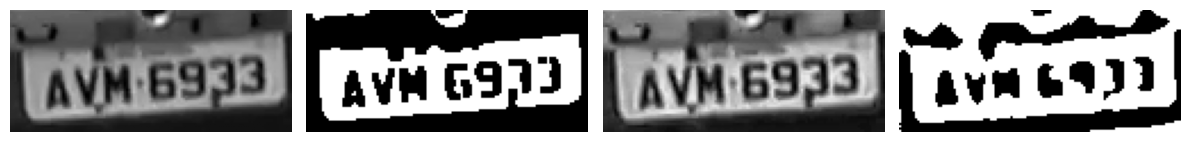

In [17]:
sample_row = df_ocr.sample(1, random_state=0).iloc[0]
plate_example = sample_row["plate_img_bgr"]

preproc_variants = ["none", "morph", "clahe", "bilateral_adaptive"]

plot_plate_preprocessing_grid(
    plate_example,
    preproc_variants,
    figsize=(12, 6),
)

## 4. Ejecutar OCRs sobre el dataset de patentes

Se corre Tesseract, EasyOCR y fast-plate-ocr sobre cada patente detectada y cada variante de preprocesamiento.


In [18]:
methods = ["tesseract", "easyocr", "fastplate"]
variants = preproc_variants

df_ocr_results = run_ocr_on_dataset(
    df_ocr,
    variants=variants,
    methods=methods,
)

print("Filas en resultados de OCR:", len(df_ocr_results))
df_ocr_results[["method", "preproc", "plate_text_gt", "plate_text_pred"]].head()


[run_ocr_on_dataset] filas df_ocr entrada: 27
[run_ocr_on_dataset] métodos: ['tesseract', 'easyocr', 'fastplate']
[run_ocr_on_dataset] variantes: ['none', 'morph', 'clahe', 'bilateral_adaptive']


c:\Users\bianc\Vision\tpf\speed\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[run_ocr_on_dataset] filas resultados: 324 (esperadas: 324)
[run_ocr_on_dataset] métodos presentes: ['easyocr', 'fastplate', 'tesseract']
[run_ocr_on_dataset] preprocs presentes: ['bilateral_adaptive', 'clahe', 'morph', 'none']
Filas en resultados de OCR: 324


,method,preproc,plate_text_gt,plate_text_pred
0,tesseract,none,,APN7771P
1,easyocr,none,,APN7774
2,fastplate,none,,APN7771
3,tesseract,morph,,7
4,easyocr,morph,,IPN7571


## 5. Métricas globales de OCR (en figuras)

Se calculan métricas agregadas por método y preprocesamiento y se muestran:

- Barplot de porcentaje de lecturas que “parecen patente” (`looks_plate_pct`).
- Barplot de porcentaje de lecturas no vacías (`non_empty_pct`).
- Tabla de métricas renderizada como figura para pegar en el informe.


[compute_ocr_metrics] filas de entrada: 324
[compute_ocr_metrics] filas con GT no vacío: 0
[compute_ocr_metrics] no hay GT de texto, métricas sin accuracy (solo non_empty_pct / looks_plate_pct / avg_len_pred).
Columnas de df_ocr_summary: ['method', 'preproc', 'total', 'accuracy', 'non_empty_pct', 'looks_plate_pct', 'avg_len_pred']
[plot_ocr_summary_bars] filas df_summary: 12, métrica: looks_plate_pct


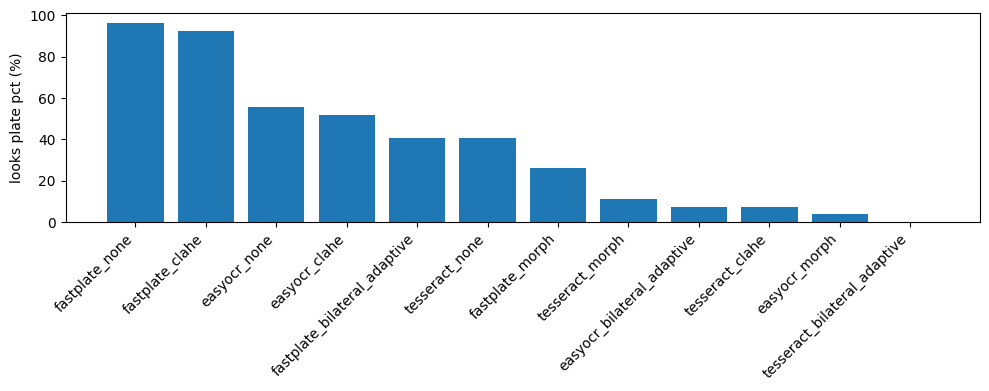

[plot_ocr_summary_bars] filas df_summary: 12, métrica: non_empty_pct


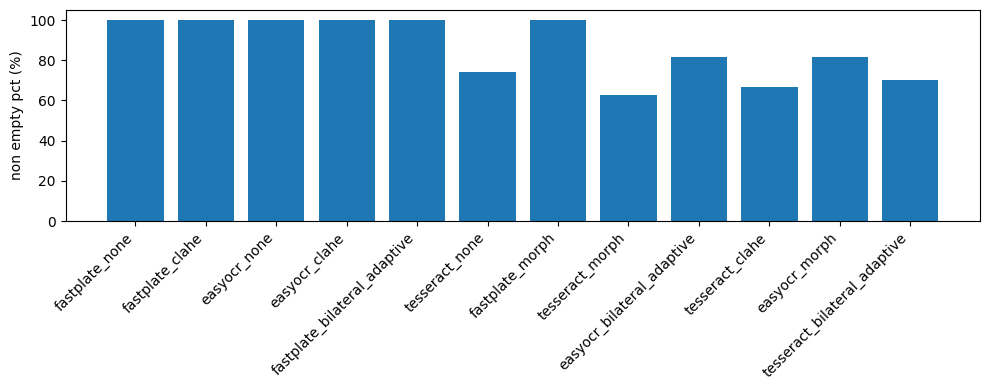

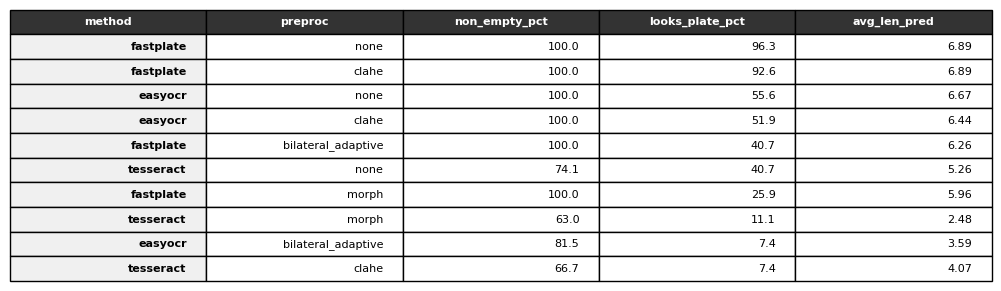

In [21]:
df_ocr_summary = compute_ocr_metrics(df_ocr_results)
print("Columnas de df_ocr_summary:", list(df_ocr_summary.columns))

df_ocr_summary_sorted = df_ocr_summary.sort_values(
    ["looks_plate_pct", "non_empty_pct"],
    ascending=False,
)

plot_ocr_summary_bars(
    df_ocr_summary_sorted,
    metric="looks_plate_pct",
    figsize=(10, 4),
)

plot_ocr_summary_bars(
    df_ocr_summary_sorted,
    metric="non_empty_pct",
    figsize=(10, 4),
)

df_ocr_summary_table = df_ocr_summary_sorted.drop(columns=["total"])

plot_table_as_image(
    df_ocr_summary_table,
    max_rows=10,
    figsize=(10, 3),
    fontsize=8,
)

## 6. Ejemplos visuales de FastPlate

Se muestran ejemplos de recortes de patente con la lectura de FastPlate:

- Grilla 2×2 con 4 ejemplos.
- Grilla 2×1 con 2 ejemplos.
- Un único ejemplo en grande.

En cada imagen se anota el texto ground truth (si está disponible) y el texto leído por FastPlate.


Filas en df_ocr_vis: 108
[_select_fastplate_examples] filas fastplate: 108
[_select_fastplate_examples] ejemplos seleccionados (good): 4
[_plot_fastplate_grid] grid 2x2, pedidos=4, reales=4, mode=good


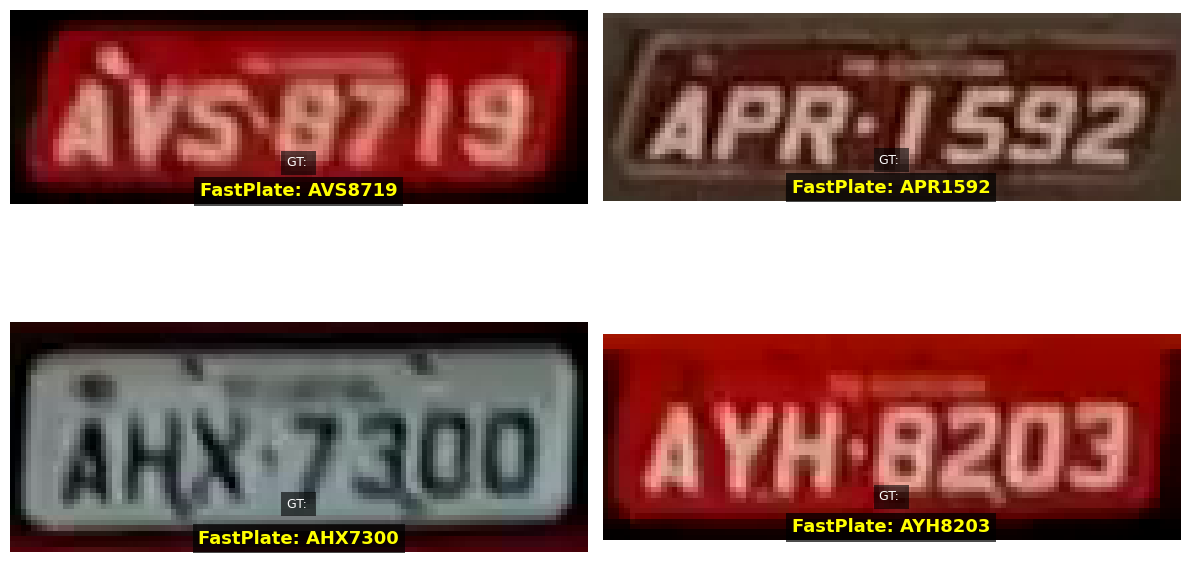

[_select_fastplate_examples] filas fastplate: 108
[_select_fastplate_examples] ejemplos seleccionados (good): 2
[_plot_fastplate_grid] grid 2x1, pedidos=2, reales=2, mode=good


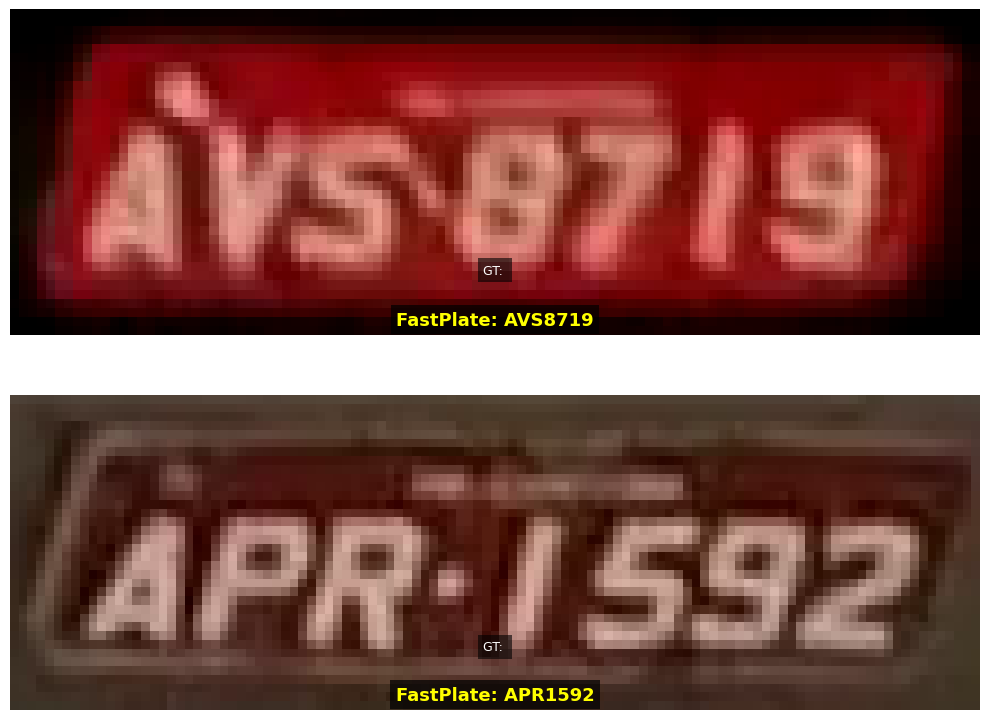

[_select_fastplate_examples] filas fastplate: 108
[_select_fastplate_examples] ejemplos seleccionados (good): 1
[_plot_fastplate_grid] grid 1x1, pedidos=1, reales=1, mode=good


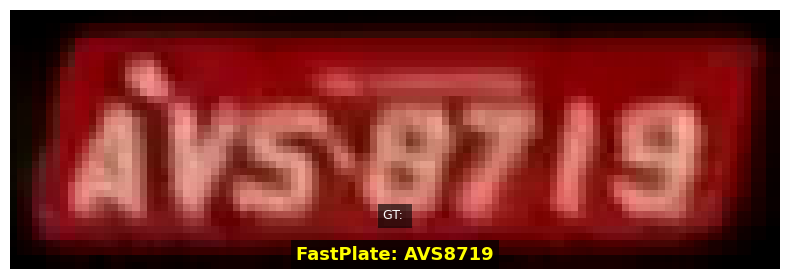

In [22]:
merge_cols = ["frame", "lane", "xml_idx"]

df_fastplate = df_ocr_results[df_ocr_results["method"] == "fastplate"].copy()
df_ocr_vis = df_ocr.merge(
    df_fastplate,
    on=merge_cols,
    how="inner",
    suffixes=("_crop", ""),
)

print("Filas en df_ocr_vis:", len(df_ocr_vis))

plot_fastplate_best_2x2(
    df_ocr_vis,
    mode="good",
    figsize=(12, 8),
)

plot_fastplate_best_2x1(
    df_ocr_vis,
    mode="good",
    figsize=(10, 8),
)

plot_fastplate_best_single(
    df_ocr_vis,
    mode="good",
    figsize=(8, 6),
)